# Sección 7. Comunidades

El análisis usa la proyección autor-autor ponderada. Cada comunidad agrupa cuentas con patrones similares de co-participación dentro de los videos recolectados.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display

import eda
import red

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
B = red.build_bipartita(comments)
A = red.proj_autores(B)
V = red.proj_videos(B)

## 7.1. Selección de la red

In [2]:
display(pd.DataFrame([
    {
        "red": "autor-autor",
        "nodos": A.number_of_nodes(),
        "aristas": A.number_of_edges(),
        "densidad": nx.density(A),
        "aislados": nx.number_of_isolates(A),
    },
    {
        "red": "video-video",
        "nodos": V.number_of_nodes(),
        "aristas": V.number_of_edges(),
        "densidad": nx.density(V),
        "aislados": nx.number_of_isolates(V),
    },
]).round(4))

display(Markdown(
    f"Se usa la proyección autor-autor porque permite agrupar las **{A.number_of_nodes()} cuentas** "
    "según videos compartidos. La proyección video-video solo contiene "
    f"**{V.number_of_edges()} aristas** y **{nx.number_of_isolates(V)} videos aislados**. "
    "Louvain ordinario tampoco modela directamente los dos tipos de nodo de la red bipartita. "
    "La elección responde a la pregunta sobre comunidades de participación, no a una supuesta "
    "relación social entre autores."
))

,red,nodos,aristas,densidad,aislados
0,autor-autor,332,10732,0.1953,4
1,video-video,19,11,0.0643,9


Se usa la proyección autor-autor porque permite agrupar las **332 cuentas** según videos compartidos. La proyección video-video solo contiene **11 aristas** y **9 videos aislados**. Louvain ordinario tampoco modela directamente los dos tipos de nodo de la red bipartita. La elección responde a la pregunta sobre comunidades de participación, no a una supuesta relación social entre autores.

## 7.2. Algoritmo y tratamiento de pesos

In [3]:
comunidades_crudas = nx.community.louvain_communities(
    A,
    weight="weight",
    resolution=1,
    seed=42,
)
comunidades_ordenadas = sorted(comunidades_crudas, key=len, reverse=True)
asignacion = {
    node: numero
    for numero, comunidad in enumerate(comunidades_ordenadas, start=1)
    for node in comunidad
}

assert set(asignacion) == set(A)
assert sum(map(len, comunidades_ordenadas)) == A.number_of_nodes()

modularidad = nx.community.modularity(A, comunidades_ordenadas, weight="weight")
display(Markdown(
    "Louvain maximiza la modularidad mediante movimientos locales de nodos. Se fijó la "
    "semilla en 42 para reproducir la partición y se usó `weight='weight'`. En esta red, "
    "el peso es el número de videos compartidos. La resolución se mantuvo en 1, su valor "
    "estándar. Los aislados permanecen como comunidades de un nodo."
))

Louvain maximiza la modularidad mediante movimientos locales de nodos. Se fijó la semilla en 42 para reproducir la partición y se usó `weight='weight'`. En esta red, el peso es el número de videos compartidos. La resolución se mantuvo en 1, su valor estándar. Los aislados permanecen como comunidades de un nodo.

## 7.3. Número, tamaños y modularidad

In [4]:
comunidades = pd.DataFrame({
    "nodo": list(A.nodes()),
    "comunidad": [asignacion[n] for n in A],
    "tamano_comunidad": [len(comunidades_ordenadas[asignacion[n] - 1]) for n in A],
    "author_name": [A.nodes[n].get("author_name", "") for n in A],
    "author_handle": [A.nodes[n].get("author_handle", "") for n in A],
    "grado": [A.degree(n) for n in A],
})
comunidades = comunidades.sort_values(["comunidad", "grado"], ascending=[True, False])
comunidades.to_csv(TABLAS / "comunidades.csv", index=False)

resumen = (
    comunidades.groupby("comunidad")
    .agg(autores=("nodo", "size"), grado_medio=("grado", "mean"))
    .reset_index()
)
resumen["porcentaje_autores"] = 100 * resumen["autores"] / A.number_of_nodes()
resumen["modularidad_particion"] = modularidad
resumen.to_csv(TABLAS / "comunidades_resumen.csv", index=False)

display(resumen.round(4))
display(Markdown(
    f"Louvain detectó **{len(comunidades_ordenadas)} comunidades**. La mayor contiene "
    f"**{len(comunidades_ordenadas[0])} autores** y la modularidad ponderada es "
    f"**{modularidad:.3f}**. La partición incluye "
    f"**{sum(len(c) == 1 for c in comunidades_ordenadas)} comunidades unitarias**, "
    "que corresponden a autores aislados en la proyección."
))

,comunidad,autores,grado_medio,porcentaje_autores,modularidad_particion
0,1,126,127.1905,37.9518,0.3949
1,2,61,24.1311,18.3735,0.3949
2,3,55,48.2727,16.5663,0.3949
3,4,28,12.4643,8.4337,0.3949
4,5,25,24.0000,7.5301,0.3949
5,6,18,17.0000,5.4217,0.3949
6,7,6,6.0000,1.8072,0.3949
7,8,4,3.0000,1.2048,0.3949
8,9,3,2.0000,0.9036,0.3949
9,10,2,1.0000,0.6024,0.3949


Louvain detectó **14 comunidades**. La mayor contiene **126 autores** y la modularidad ponderada es **0.395**. La partición incluye **4 comunidades unitarias**, que corresponden a autores aislados en la proyección.

## 7.4. Visualización de todas las comunidades

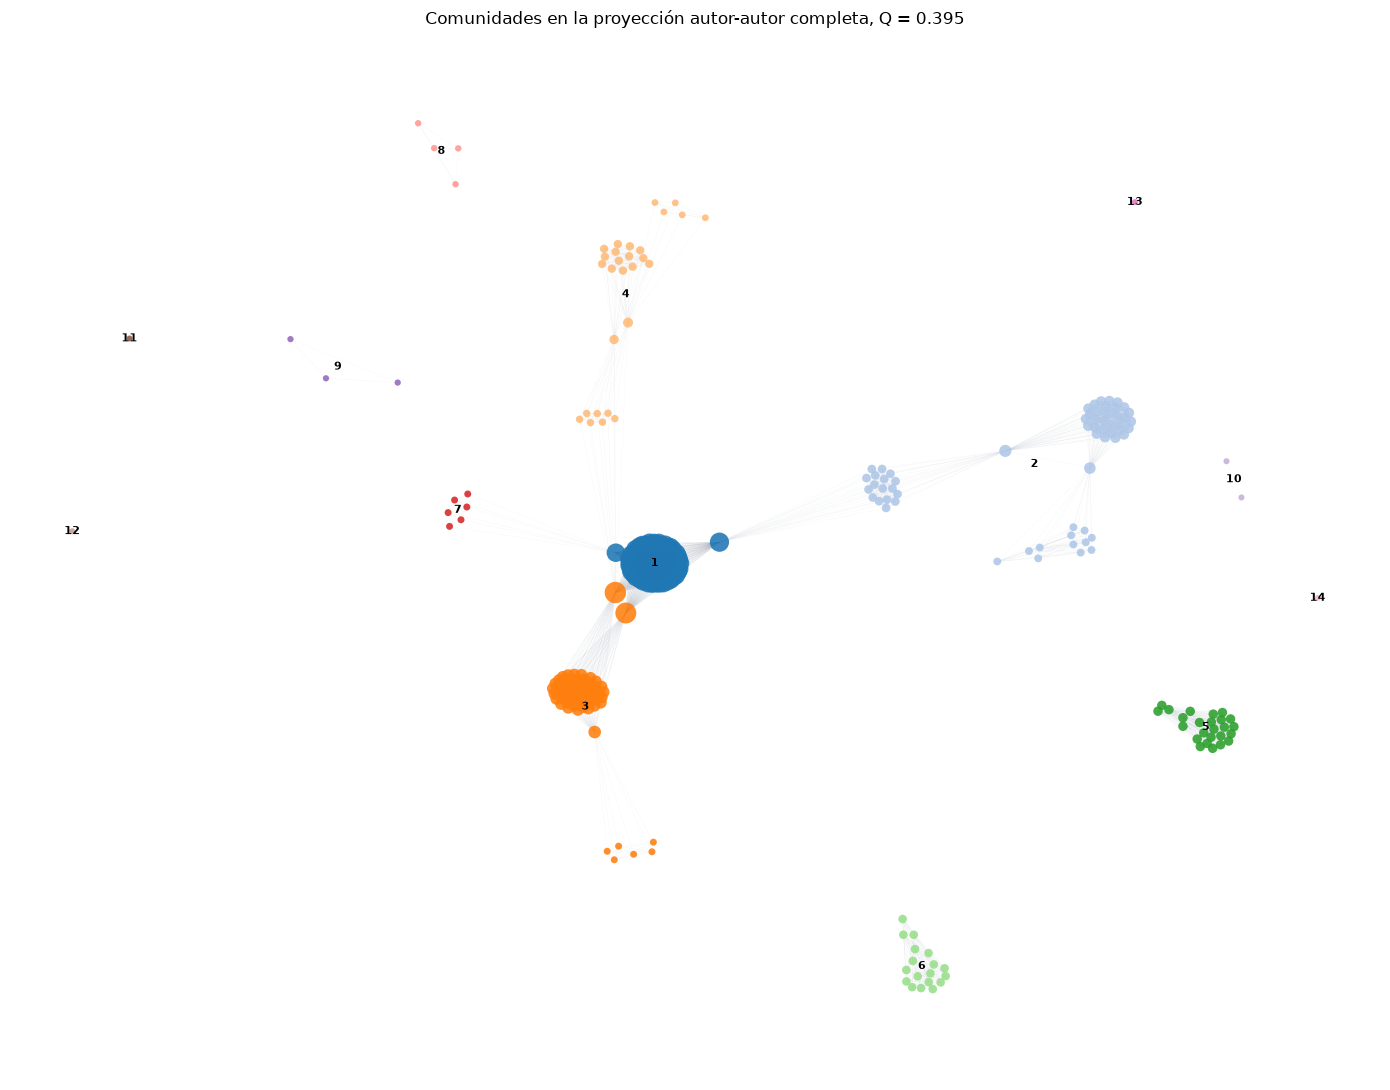

In [5]:
pos = nx.spring_layout(A, seed=42, weight="weight", k=0.22, iterations=80)
colores = plt.cm.tab20([i % 20 for i in range(len(comunidades_ordenadas))])
color_nodo = [colores[asignacion[n] - 1] for n in A]

fig, ax = plt.subplots(figsize=(14, 11))
nx.draw_networkx_edges(A, pos, edge_color="#64748b", width=0.25, alpha=0.07, ax=ax)
nx.draw_networkx_nodes(
    A,
    pos,
    node_color=color_nodo,
    node_size=[18 + 1.2 * A.degree(n) for n in A],
    alpha=0.88,
    linewidths=0,
    ax=ax,
)
for numero, comunidad in enumerate(comunidades_ordenadas, start=1):
    x = sum(pos[n][0] for n in comunidad) / len(comunidad)
    y = sum(pos[n][1] for n in comunidad) / len(comunidad)
    ax.text(x, y, str(numero), fontsize=8, weight="bold", ha="center", va="center")
ax.set_title(
    f"Comunidades en la proyección autor-autor completa, Q = {modularidad:.3f}"
)
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURAS / "07_comunidades_autores.png", dpi=180, bbox_inches="tight")
plt.show()

## 7.5. Caracterización de las tres comunidades principales

In [6]:
comments_perfil = comments.assign(tono_emoji=eda.sentimiento_emoji(comments))
video_info = videos.set_index("video_id")
filas_caracterizacion = []
filas_palabras = []

for numero in range(1, min(3, len(comunidades_ordenadas)) + 1):
    autores_comunidad = set(
        comunidades.loc[comunidades["comunidad"] == numero, "nodo"]
    )
    subset = comments_perfil[
        comments_perfil["author_channel_id"].isin(autores_comunidad)
    ]
    conteos_video = subset.groupby("video_id").size().sort_values(ascending=False)
    conteos_canal = subset.groupby("channel_name").size().sort_values(ascending=False)
    palabras = eda.frecuencias_palabras(subset["texto_limpio"], n=8)
    con_emoji = subset[subset["n_emojis"] > 0]
    tono = con_emoji["tono_emoji"].value_counts()

    titulos = [
        f"{video_info.loc[video_id, 'title']} ({n})"
        for video_id, n in conteos_video.head(3).items()
    ]
    canales = [f"{canal} ({n})" for canal, n in conteos_canal.head(3).items()]
    terminos = [
        f"{fila.palabra} ({fila.frecuencia})" for fila in palabras.itertuples()
    ]

    filas_caracterizacion.append({
        "comunidad": numero,
        "autores": len(autores_comunidad),
        "comentarios": len(subset),
        "comentarios_por_autor": len(subset) / len(autores_comunidad),
        "videos": subset["video_id"].nunique(),
        "canales": subset["channel_id"].nunique(),
        "videos_principales": "; ".join(titulos),
        "canales_principales": "; ".join(canales),
        "comentarios_con_emoji": len(con_emoji),
        "tono_emoji_positivo": int(tono.get(1, 0)),
        "tono_emoji_negativo": int(tono.get(-1, 0)),
        "tono_emoji_sin_direccion": int(tono.get(0, 0)),
    })
    palabras = palabras.assign(comunidad=numero)
    filas_palabras.append(palabras)

    display(Markdown(
        f"### Comunidad {numero}\n\n"
        f"Reúne **{len(autores_comunidad)} autores**, **{len(subset)} comentarios**, "
        f"**{subset['video_id'].nunique()} videos** y **{subset['channel_id'].nunique()} canales**. "
        f"La intensidad es de **{len(subset) / len(autores_comunidad):.2f} comentarios por autor**.\n\n"
        f"Videos con más comentarios de la comunidad: {', '.join(titulos)}.\n\n"
        f"Canales con más comentarios: {', '.join(canales)}.\n\n"
        f"Palabras más frecuentes: {', '.join(terminos)}.\n\n"
        f"Solo **{len(con_emoji)} de {len(subset)} comentarios** contienen emojis. Entre ellos, "
        f"el indicador encuentra **{int(tono.get(1, 0))} con dirección positiva**, "
        f"**{int(tono.get(-1, 0))} con dirección negativa** y "
        f"**{int(tono.get(0, 0))} sin dirección**."
    ))

caracterizacion = pd.DataFrame(filas_caracterizacion)
palabras_comunidad = pd.concat(filas_palabras, ignore_index=True)
caracterizacion.to_csv(TABLAS / "comunidades_caracterizacion.csv", index=False)
palabras_comunidad.to_csv(TABLAS / "comunidades_palabras.csv", index=False)
display(caracterizacion.round(3))

### Comunidad 1

Reúne **126 autores**, **161 comentarios**, **3 videos** y **3 canales**. La intensidad es de **1.28 comentarios por autor**.

Videos con más comentarios de la comunidad: Qué rico come tu diputado (159), Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt (1), Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales (1).

Canales con más comentarios: Quorum (159), Gobierno de la República de Guatemala (1), PrensaLibreOficial (1).

Palabras más frecuentes: pueblo (50), diputado (48), pagar (36), hacer (35), dinero (27), él (25), trabajo (21), decir (21).

Solo **10 de 161 comentarios** contienen emojis. Entre ellos, el indicador encuentra **4 con dirección positiva**, **5 con dirección negativa** y **1 sin dirección**.

### Comunidad 2

Reúne **61 autores**, **83 comentarios**, **3 videos** y **2 canales**. La intensidad es de **1.36 comentarios por autor**.

Videos con más comentarios de la comunidad: Inician los trabajos de recuperación del Puente Belice II. (45), Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt (24), Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto (14).

Canales con más comentarios: Gobierno de la República de Guatemala (69), Noti7 (14).

Palabras más frecuentes: presidente (26), hacer (17), guatemala (16), país (13), año (12), arevalo (10), terminar (10), proyecto (9).

Solo **20 de 83 comentarios** contienen emojis. Entre ellos, el indicador encuentra **15 con dirección positiva**, **1 con dirección negativa** y **4 sin dirección**.

### Comunidad 3

Reúne **55 autores**, **60 comentarios**, **4 videos** y **2 canales**. La intensidad es de **1.09 comentarios por autor**.

Videos con más comentarios de la comunidad: La cooptación de Walter Mazariegos en la USAC (50), Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu (7), Qué rico come tu diputado (2).

Canales con más comentarios: Quorum (53), TN23 Guatemala (7).

Palabras más frecuentes: corrupto (10), usac (9), él (7), poder (7), estudiante (7), universidad (6), información (6), buen (5).

Solo **12 de 60 comentarios** contienen emojis. Entre ellos, el indicador encuentra **4 con dirección positiva**, **4 con dirección negativa** y **4 sin dirección**.

,comunidad,autores,comentarios,comentarios_por_autor,videos,canales,videos_principales,canales_principales,comentarios_con_emoji,tono_emoji_positivo,tono_emoji_negativo,tono_emoji_sin_direccion
0,1,126,161,1.278,3,3,Qué rico come tu diputado (159); Conferencia d...,Quorum (159); Gobierno de la República de Guat...,10,4,5,1
1,2,61,83,1.361,3,2,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala (69); No...,20,15,1,4
2,3,55,60,1.091,4,2,La cooptación de Walter Mazariegos en la USAC ...,Quorum (53); TN23 Guatemala (7),12,4,4,4


El indicador por emojis no sustituye un modelo de sentimiento en español. Solo describe la dirección de los emojis presentes y deja sin clasificar el texto sin emoji. El análisis formal de sentimiento corresponde al inciso 9.

La modularidad y las comunidades dependen de la proyección. Cada video convierte a sus comentaristas en un grupo totalmente conectado, aunque no exista interacción directa entre ellos. Por ello, estas comunidades describen patrones de co-participación en la muestra y no grupos sociales comprobados.